In [ ]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
path = '/workspaces/protein-aggregation/genetic_instances/instance2'
all_fitness_data = []
individual_fitness_records = []

In [ ]:
for i in range(21):
    file_path = os.path.join(path, f'generation_{i}.json')

    with open(file_path, 'r') as f:
        data = json.load(f)
        fitness_scores = [individual['fitness'] for individual in data['population']]

        if fitness_scores:
            best_fitness = max(fitness_scores)
            avg_fitness = sum(fitness_scores)/len(fitness_scores)
            min_fitness = min(fitness_scores)

            all_fitness_data.append({
                'generation': i,
                'best_fitness': best_fitness,
                'avg_fitness': avg_fitness,
                'min_fitness': min_fitness
            })

        for score in fitness_scores:
            individual_fitness_records.append({
                'generation': i,
                'fitness': score
            })

In [ ]:
df_convergence = pd.DataFrame(all_fitness_data)
df_individuals = pd.DataFrame(individual_fitness_records)

In [ ]:
print(df_convergence)

## Fitness evolution 

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(df_convergence['generation'], df_convergence['best_fitness'], label='Best Fitness', color='blue',linestyle='-')
plt.plot(df_convergence['generation'], df_convergence['avg_fitness'], label='Mean Fitness', color='orange', linestyle='-')
plt.plot(df_convergence['generation'], df_convergence['min_fitness'], label='Worst Fitness', color='red', linestyle='-')
plt.title('Fitness evolution over generations')
plt.xlabel('Generation')
plt.ylabel('Fitness score')
plt.legend()
plt.xticks(df_convergence['generation'])
#plt.grid()
plt.show()

In [ ]:
generations_to_plot = [1, 5, 10, 15, 20]
df_filtered = df_individuals[df_individuals['generation'].isin(generations_to_plot)]

In [ ]:
plt.figure(figsize=(8, 5))

sns.violinplot(
    data=df_filtered, 
    x='generation', 
    y='fitness',
    #palette='', 
    inner='quartile'   
)

plt.title('Violin plot of the fitness over generations', fontsize=16)
plt.xlabel('Generation', fontsize=12)
plt.ylabel('Fitness Value', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

## Frequency HeatMap

In [ ]:
final_generation = 6
caminho_final = os.path.join(path, f'generation_{final_generation}.json')
sequencias_finais = []

In [ ]:
with open(caminho_final, 'r') as f:
    data = json.load(f)
    if 'population' in data and all('sequence' in ind for ind in data['population']):
        sequencias_finais = [ind['sequence'] for ind in data['population']]

In [ ]:
aminoacidos = sorted("ACDEFGHIKLMNPQRSTVWY")
comprimento_sequencia = len(sequencias_finais[0])

matriz_frequencia = pd.DataFrame(0, index=aminoacidos, columns=range(1, comprimento_sequencia + 1))

for seq in sequencias_finais:
    if len(seq) == comprimento_sequencia:
        for i, aa in enumerate(seq):
            if aa in aminoacidos:
                matriz_frequencia.loc[aa, i + 1] += 1

matriz_frequencia = matriz_frequencia / len(sequencias_finais)

plt.figure(figsize=(20, 10)) 

sns.heatmap(
        data=matriz_frequencia,
        cmap='magma',  
        linewidths=.2,
        linecolor='black'
    )

plt.title(f'Amino Acid Frequency Heatmap of the Most Promising Generation ({final_generation})', fontsize=18)
plt.xlabel('Position in the Sequence', fontsize=14)
plt.ylabel('Amino acid', fontsize=14)
plt.xticks(rotation=45) 
plt.yticks(rotation=0)  
plt.show()


## Percentage identity

In [ ]:
import glob

reference = "GIVEQCCTSICSLYQLENYCNFVNQHLCGSHLVEALYLVCGERGFFYTPKA"

def calc_identity(seq: str, ref: str) -> float:
    """
    Calculate percent identity between seq and ref.
    """
    matches = sum(1 for a, b in zip(seq, ref) if a == b)
    return matches / len(ref) * 100

results = []
for filepath in sorted(glob.glob("/workspaces/protein-aggregation/genetic_instances/instance2/generation_*.json")):
    gen_number = int(os.path.basename(filepath).split('_')[1].split('.')[0])
    with open(filepath, 'r') as f:
        data = json.load(f)
        population = data.get("population", [])
        sequences = [individual["sequence"] for individual in population]
        identities = [calc_identity(seq.strip(), reference) for seq in sequences]

        best_id = max(identities)
        avg_id  = sum(identities) / len(identities)
        results.append((gen_number, best_id, avg_id))
    
results.sort()

print(f"{'Generation':<15} {'Best (%)':>6} {'Average (%)':>12}")
print("-"*37)
for gen, best, avg in results:
    print(f"{gen:<15} {best:8.1f} {avg:12.1f}")

## Scatter plot

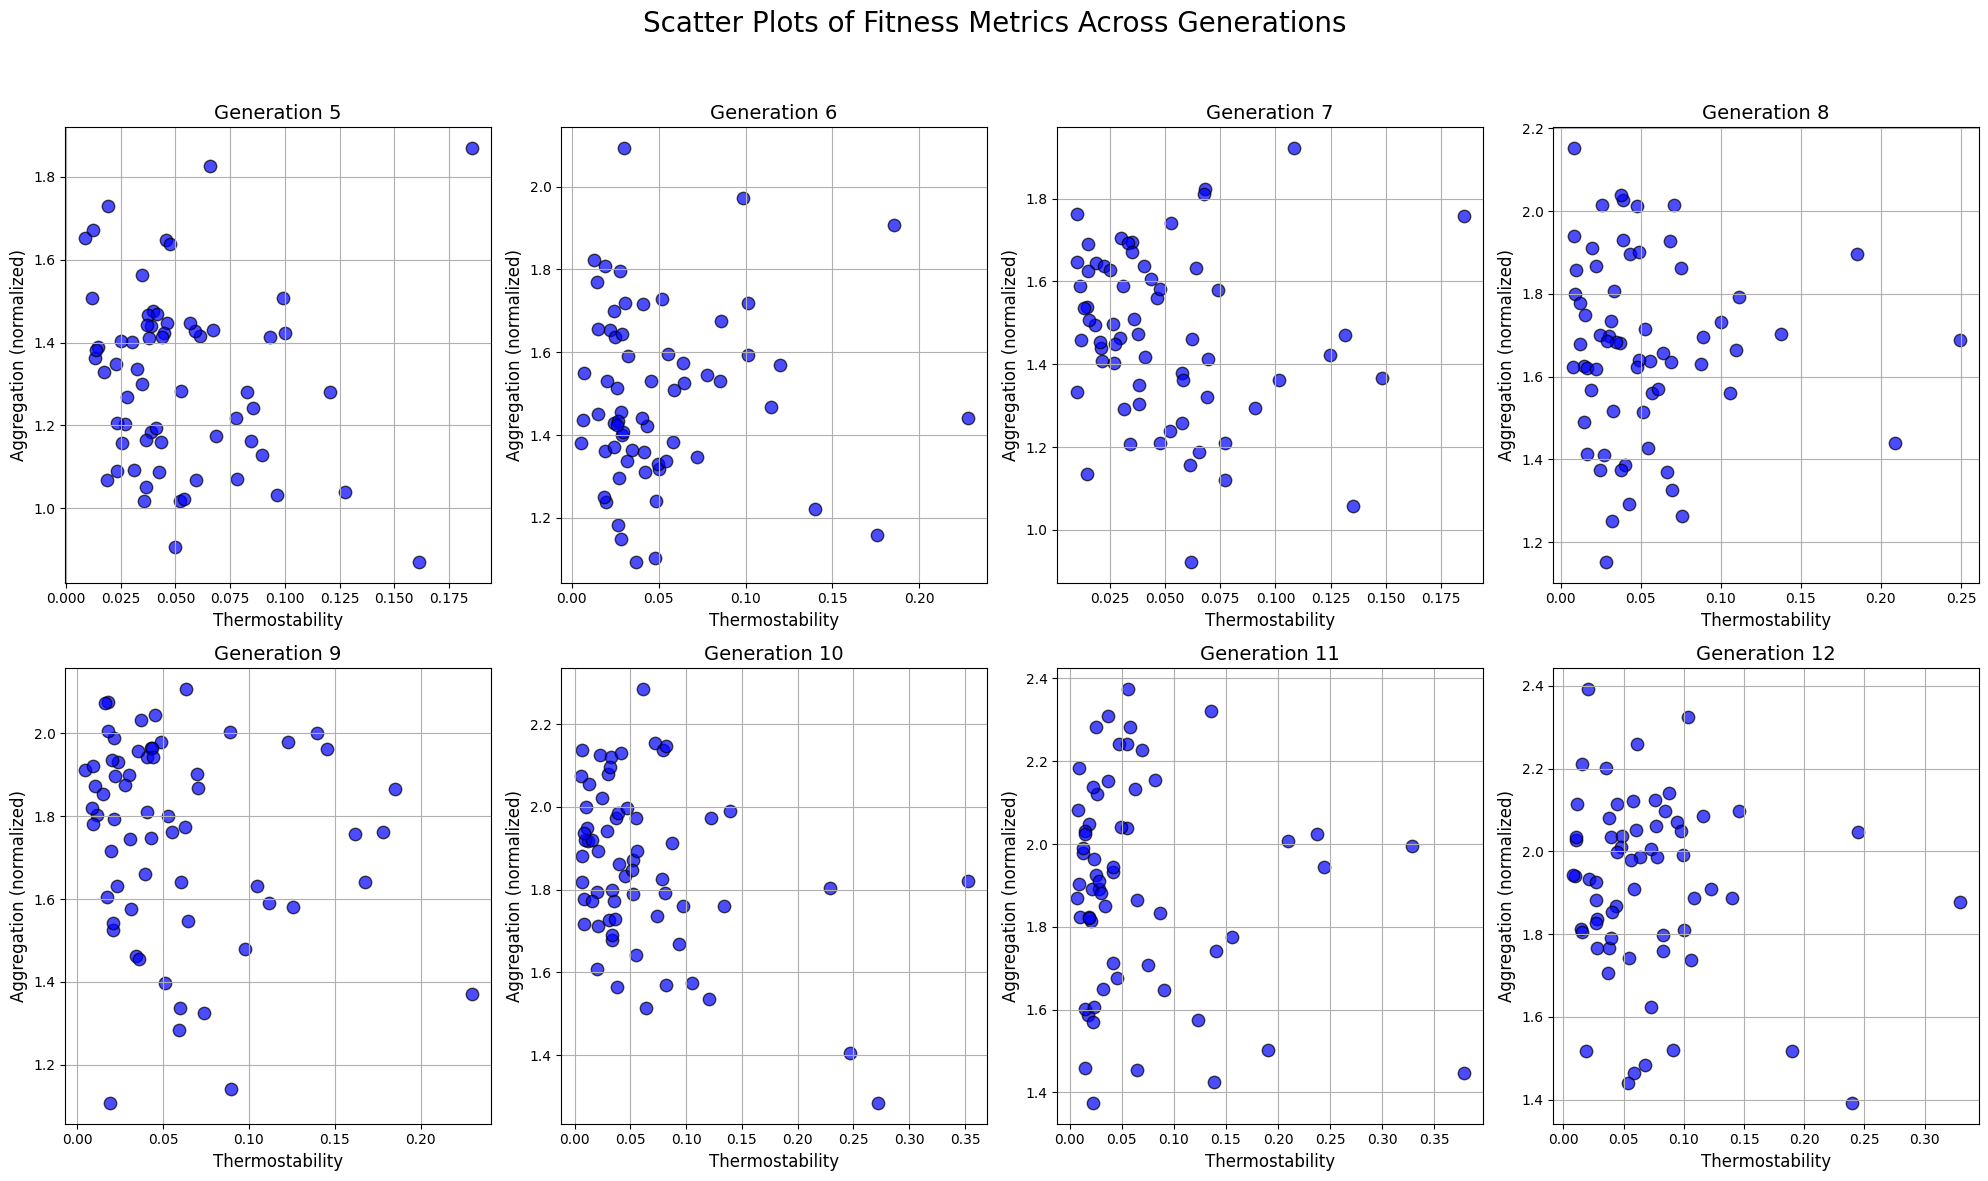

In [ ]:
import numpy as np

plt.figure(figsize=(20, 12))
for idx, gen_num in enumerate(range(5, 13)):
    for filepath in sorted(glob.glob(f"/workspaces/protein-aggregation/genetic_instances/instance2/generation_{gen_num}.json")):
        with open(filepath, 'r') as f:
            data = json.load(f)
            population = data.get("population", [])
            thermo = [individual["thermostability"] for individual in population] 
            aggre = [individual["aggregation"] for individual in population]
            aggre_valid = [a for a in aggre if a is not None]
            if aggre_valid:
                a_min = min(aggre_valid)
                a_max = max(aggre_valid)
            else:
                a_min = a_max = 0  
            norm_aggr = [1 - (a/(a_max - a_min)) if a is not None and (a_max - a_min) != 0 else None for a in aggre]
        
        ax = plt.subplot(2, 4, idx + 1)
        ax.scatter(thermo, norm_aggr, color= 'blue', alpha=0.7, edgecolor='k', s=80)
        ax.set_title(f"Generation {gen_num}", fontsize=14)
        ax.set_xlabel("Thermostability", fontsize=12)
        ax.set_ylabel("Aggregation (normalized)", fontsize=12)
        ax.grid(True)

plt.suptitle("Scatter Plots of Fitness Metrics Across Generations", fontsize=20)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()